# R19-B retrieval forensics: fragmentation-vs-dilution, near-domain miss, probe power

**Author**: Claude (executor)  **Date**: 2026-07-07  **Graphs**: baseline neo4j2 + SOTA rebuild neo4j (both READ-ONLY)

Three registered hypotheses on the R09/H61 render harness lineage. **H184** decomposes why the richer SOTA rebuild
retrieves worse than the leaner baseline at matched k=16 - per-gold carrier forensics across both graphs, attributing
the deficit to type-surface *fragmentation* (evidence split across more nodes) vs embedding-text *dilution* (the single
equivalent carrier simply ranks lower). **H185** hardens the H181 abstention detector against near-domain unanswerable
probes (right product, absent fact). **H186** builds a wide deterministic probe set and asks whether the 33-gold
instrument has enough statistical power for the 2%/5% bars, and whether v28-era conclusions survive on the wide set.

No LLM generation anywhere - deterministic template synthesis, the H34 fuzzy-evidence matcher, tiktoken cl100k token
counts, and Bedrock Titan query embeddings (the sanctioned probe-seed mechanism, cached to disk). The contaminated SOTA
instance (26 original docs + 76 wave-2 `c77_*.txt` docs) is used read-only; H184 rank forensics **exclude** entities
whose provenance is wave-2-only.

In [1]:
# Imports
import os, re, json, math, pickle, hashlib, datetime
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml, tiktoken
from rich import print as rprint
from neo4j import GraphDatabase

os.environ["NEO4J_URI"]="bolt://user-konrad.jelen-kgf-neo4j2:7687"   # baseline, READ-ONLY
os.environ["NEO4J_USER"]="neo4j"; os.environ["NEO4J_PASSWORD"]="kgfoundry"
np.random.seed(42)
ROOT=Path("..")

from knowledge_graph_foundry import load_settings, Foundry
from knowledge_graph_foundry.extraction import generate_embeddings
from knowledge_graph_foundry.graph.graphrag import vector_query
from knowledge_graph_foundry.models import Entity

ENC=tiktoken.get_encoding("cl100k_base")
def TT(s): return len(ENC.encode(s or ""))
settings=load_settings(ROOT/"config.yml")
VEC_INDEX=settings.graphrag.vector_index_name
TOP_K=settings.graphrag.top_k
BASE_URI="bolt://user-konrad.jelen-kgf-neo4j2:7687"
SOTA_URI="bolt://user-konrad.jelen-kgf-neo4j:7687"

# Deterministic fuzzy-evidence matcher - verbatim from the H34/H61 harness
def _norm(s): return re.sub(r"\s+"," ",(s or "").casefold())
def value_tokens(t): return re.findall(r"[\w.\-/]*\d[\w.\-/]*", t or "")
_UNIT=r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"
def present(gold, ctx):
    ng=_norm(gold)
    if ng in ctx: return True
    sq=re.sub(r"[\s,()]","",ctx); sk=re.sub(r"[\s,()]","",re.sub(_UNIT,"",ng))
    if any(c.isdigit() for c in sk) and len(sk)>=5 and sk in sq: return True
    tok=value_tokens(gold)
    if tok:
        hit=sum(1 for t in tok if _norm(t) in ctx or re.sub(r"[\s,()]","",_norm(t)) in sq)
        return hit>=max(1,len(tok)//2+(len(tok)%2))
    w=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ng)); cw=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ctx))
    return bool(w) and len(w&cw)/len(w)>=0.6
def is_shortnum(g):
    t=value_tokens(g); return bool(t) and sum(len(re.sub(r"[^\d]","",x)) for x in t)<=3
def unit(v):
    a=np.array(v,dtype=np.float32); n=np.linalg.norm(a); return a/n if n else a

# Query embedding cache (Titan, deterministic re-execution). Seeds from the token-economy cache for the shared 24 probes.
QCACHE=Path(".forensics_r19b_qcache.pkl")
qcache=pickle.load(open(QCACHE,"rb")) if QCACHE.exists() else {}
TE=Path(".token_economy_r19_qcache.pkl")
if TE.exists():
    for k,v in pickle.load(open(TE,"rb")).items(): qcache.setdefault(k,v)
def key(q): return hashlib.md5(q.encode()).hexdigest()
def qemb(q):
    k=key(q)
    if k not in qcache:
        qcache[k]=generate_embeddings([Entity.create(q[:80],types=["Query"],description=q)], settings.embeddings)[0].embedding
    return qcache[k]
rprint("[green]harness ready[/green]  tiktoken cl100k_base | H34 fuzzy matcher | Titan query embeddings (cached)")

2026-07-07 15:10:53.685 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


harness ready  tiktoken cl100k_base | H34 fuzzy matcher | Titan query embeddings (cached)

## Graph pull and render primitives

One read-only pull per graph: entities with 1024-dim Titan embeddings, native-typed edges (SIMILAR_TO excluded),
propositions, and per-entity `source_documents` provenance. `render_nodes` reproduces the three-arm-benchmark
convention (base + <=15 relations, no propositions, no alias) that produced the 0.854 baseline / 0.729 SOTA headline;
`carrier_text` is the fuller node content (base + propositions) where a gold's evidence actually sits. On the SOTA
graph, wave-2 documents are the `c77_*.txt` filenames; an entity is dropped from rank forensics only if **all** its
provenance is wave-2.

In [2]:
def pull(uri):
    d=GraphDatabase.driver(uri,auth=("neo4j","kgfoundry"))
    with d.session() as s:
        ents=s.run("MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
                   "properties(e) AS props, labels(e) AS types, e.embedding AS emb, e.source_documents AS sd").data()
        edges=s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r)<>'SIMILAR_TO' AND a.id<b.id "
                    "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel").data()
        prop_rows=s.run("MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text").data()
        docmap={r["id"]:r["nm"] for r in s.run("MATCH (dd:KGFDocument) RETURN dd.id AS id, dd.name AS nm").data()}
    d.close()
    node={r["id"]:r for r in ents}; names={r["id"]:r["name"] for r in ents}
    emb_by={r["id"]:unit(r["emb"]) for r in ents if r["emb"]}
    props_by=defaultdict(list)
    for r in prop_rows: props_by[r["eid"]].append(r["text"])
    rels_by=defaultdict(list)
    for e in edges:
        rels_by[e["a"]].append((e["rel"],e["b"])); rels_by[e["b"]].append((e["rel"],e["a"]))
    return dict(node=node,names=names,emb_by=emb_by,props_by=props_by,rels_by=rels_by,docmap=docmap,ents=ents)

B=pull(BASE_URI); S=pull(SOTA_URI)

def spec_of(r): return {k.removeprefix("prop_"):v for k,v in r["props"].items() if k.startswith("prop_")}
def render_nodes(G, ids):
    blocks=[]
    for nid in ids:
        r=G["node"].get(nid)
        if r is None: continue
        spec={k.removeprefix("prop_"):v for k,v in r["props"].items() if k.startswith("prop_")}
        rl=G["rels_by"].get(nid,[])[:15]
        blocks.append(f"## {r['name']} ({', '.join(r['types'])})\n{r['description'] or ''}\n"
                      f"Properties: {json.dumps(spec,default=str)}\nRelations: "+
                      "; ".join(f"{t} -> {G['names'].get(b,'')}" for t,b in rl))
    return _norm("\n".join(blocks))
def carrier_text(G, nid):
    r=G["node"][nid]; spec=spec_of(r)
    return _norm(f"{r['name']} ({', '.join(r['types'])}) {r['description'] or ''} "
                 f"{json.dumps(spec,default=str)} "+" ".join(G["props_by"].get(nid,[])))

SOTA_WAVE2_DOCIDS={did for did,nm in S["docmap"].items() if not nm.lower().endswith(".pdf")}
def sota_is_wave2_only(nid):
    sd=S["node"][nid].get("sd") or []
    return bool(sd) and all(did in SOTA_WAVE2_DOCIDS for did in sd)
SOTA_KEEP=[nid for nid in S["node"] if not sota_is_wave2_only(nid)]

def ranked_ids(G, qv, keep):
    sims=[(nid, float(qv@G["emb_by"][nid])) for nid in keep if nid in G["emb_by"]]
    sims.sort(key=lambda x:-x[1]); return sims
def carrier_rank(G, qv, keep, gold, ranklist=None):
    rl=ranklist if ranklist is not None else ranked_ids(G,qv,keep)
    best=None; ncar=0
    for i,(nid,sim) in enumerate(rl,1):
        if present(gold, carrier_text(G,nid)):
            ncar+=1
            if best is None: best=i
    return best, ncar

probes=yaml.safe_load((ROOT/"tests/probes/cpap-probe-set.yml").read_text())
gold_probes=[p for p in probes if p.get("gold_evidence")]
GOLDS=[(p["id"],g) for p in gold_probes for g in p["gold_evidence"]]
qvec={p["id"]:unit(qemb(p["question"])) for p in gold_probes}
rprint(f"[green]pulled[/green] baseline ents [yellow]{len(B['node'])}[/yellow] | sota ents [yellow]{len(S['node'])}[/yellow] "
       f"(kept original-touching [yellow]{len(SOTA_KEEP)}[/yellow], wave2 docs [yellow]{len(SOTA_WAVE2_DOCIDS)}[/yellow]) "
       f"| probes [yellow]{len(gold_probes)}[/yellow] golds [yellow]{len(GOLDS)}[/yellow]")

pulled baseline ents 2798 | sota ents 3713 (kept original-touching 3331, wave2 docs 76) | probes 24 golds 33

## R19-H184 - fragmentation or dilution

For each of the 33 golds, locate its carrier(s) in both graphs (by fuzzy-evidence match over `carrier_text`), record the
best carrier's vector rank for the probe query in each graph, and count carriers. The forensic deficit = golds whose
carrier ranks within top-16 on the baseline but falls below 16 (or is absent) on the SOTA rebuild. Each deficit gold is
attributed to **fragmentation** (strictly more carriers in SOTA - evidence split), **dilution** (equivalent carrier(s)
exist, best rank simply fell below 16), or **absent** (no carrier at all). Bar: >=70% to one mechanism.

In [3]:
BASE_KEEP=list(B["node"].keys())
per_gold=[]
for p in gold_probes:
    qv=qvec[p["id"]]
    rl_b=ranked_ids(B,qv,BASE_KEEP); rl_s=ranked_ids(S,qv,SOTA_KEEP)
    top16_b=render_nodes(B,[nid for nid,_ in rl_b[:16]]); top16_s=render_nodes(S,[nid for nid,_ in rl_s[:16]])
    for g in p["gold_evidence"]:
        rb,nb=carrier_rank(B,qv,BASE_KEEP,g,rl_b); rs,ns=carrier_rank(S,qv,SOTA_KEEP,g,rl_s)
        per_gold.append(dict(pid=p["id"],gold=g,base_recall16=present(g,top16_b),sota_recall16=present(g,top16_s),
                             base_rank=rb,base_ncar=nb,sota_rank=rs,sota_ncar=ns))
base_rec=sum(x["base_recall16"] for x in per_gold); sota_rec=sum(x["sota_recall16"] for x in per_gold)
for x in per_gold:
    x["base_cr16"]=x["base_rank"] is not None and x["base_rank"]<=16
    x["sota_cr16"]=x["sota_rank"] is not None and x["sota_rank"]<=16
base_cr=sum(x["base_cr16"] for x in per_gold); sota_cr=sum(x["sota_cr16"] for x in per_gold)
deficit=[x for x in per_gold if x["base_cr16"] and not x["sota_cr16"]]
def classify(x):
    if x["sota_ncar"]==0: return "absent"
    if x["sota_ncar"]>x["base_ncar"]: return "fragmentation"
    return "dilution"
mech=Counter()
for x in deficit: x["mechanism"]=classify(x); mech[x["mechanism"]]+=1
dom,domn=(mech.most_common(1)[0] if deficit else (None,0))
rn_deficit=[x for x in per_gold if x["base_recall16"] and not x["sota_recall16"]]
prop_channel=[x for x in rn_deficit if x["sota_cr16"]]
h184=dict(base_render_recall16=base_rec, sota_render_recall16=sota_rec, base_carrier_recall16=base_cr,
          sota_carrier_recall16=sota_cr, n_golds=len(GOLDS), forensic_deficit=len(deficit), mechanism=dict(mech),
          dominant=dom, dominant_frac=(domn/len(deficit) if deficit else None),
          clause_one_mechanism_70=bool(deficit) and domn/len(deficit)>=0.70,
          render_deficit=len(rn_deficit), proposition_channel=len(prop_channel),
          deficit_detail=[{k:x[k] for k in ("pid","gold","base_rank","base_ncar","sota_rank","sota_ncar","mechanism")} for x in deficit])
rprint(f"[bold cyan]H184[/bold cyan] render_nodes recall@16 baseline [yellow]{base_rec}/33[/yellow] sota [yellow]{sota_rec}/33[/yellow]"
       f" | carrier-rank recall@16 baseline [yellow]{base_cr}/33[/yellow] sota [yellow]{sota_cr}/33[/yellow]")
rprint(f"  forensic deficit [yellow]{len(deficit)}[/yellow] golds  mechanism {dict(mech)}  "
       f"dominant [yellow]{dom}[/yellow] = [yellow]{domn}/{len(deficit)}[/yellow] = "
       f"[{'green' if h184['clause_one_mechanism_70'] else 'red'}]{domn/max(1,len(deficit)):.1%}[/] (bar >=70%)")
for x in deficit:
    rprint(f"  [dim]{x['pid']} {x['gold'][:24]:24} baseR={x['base_rank']} nB={x['base_ncar']} "
           f"sotaR={x['sota_rank']} nS={x['sota_ncar']} -> {x['mechanism']}[/dim]")
rprint(f"  [dim]render_nodes-deficit {len(rn_deficit)}; proposition-channel (carrier@16 but evidence only in a proposition): "
       f"{[x['pid'] for x in prop_channel]}[/dim]")

H184 render_nodes recall@16 baseline 29/33 sota 24/33 | carrier-rank recall@16 baseline 30/33 sota 25/33

forensic deficit 5 golds  mechanism {'dilution': 4, 'fragmentation': 1}  dominant dilution = 4/5 = 80.0% (bar 
>=70%)

P01 1130 g                   baseR=9 nB=6 sotaR=32 nS=5 -> dilution

P11 1130 g                   baseR=14 nB=6 sotaR=21 nS=5 -> dilution

P14 290 ml                   baseR=8 nB=13 sotaR=83 nS=5 -> dilution

P15 1.98kg                   baseR=16 nB=1 sotaR=25 nS=2 -> fragmentation

P18 27 dBA                   baseR=13 nB=50 sotaR=22 nS=44 -> dilution

render_nodes-deficit 6; proposition-channel (carrier@16 but evidence only in a proposition): ['P08']

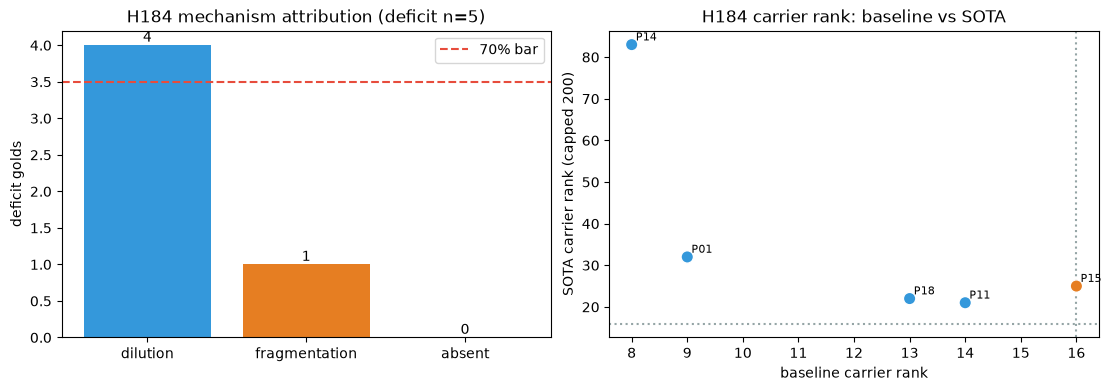

In [4]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
order=["dilution","fragmentation","absent"]; vals=[mech.get(k,0) for k in order]
ax[0].bar(order,vals,color=["#3498DB","#E67E22","#95A5A6"])
for i,v in enumerate(vals): ax[0].text(i,v+0.05,str(v),ha="center")
ax[0].axhline(0.70*len(deficit),color="#E74C3C",ls="--",label="70% bar")
ax[0].set(ylabel="deficit golds", title=f"H184 mechanism attribution (deficit n={len(deficit)})"); ax[0].legend()
rb=[x["base_rank"] for x in deficit]; rs=[min(x["sota_rank"] or 200,200) for x in deficit]
ax[1].scatter(rb,rs,c=["#3498DB" if x["mechanism"]=="dilution" else "#E67E22" for x in deficit],s=80,edgecolor="white",zorder=3)
for x,xb,xs in zip(deficit,rb,rs): ax[1].annotate(x["pid"],(xb,xs),fontsize=8,xytext=(3,3),textcoords="offset points")
ax[1].axhline(16,color="#95A5A6",ls=":"); ax[1].axvline(16,color="#95A5A6",ls=":")
ax[1].set(xlabel="baseline carrier rank", ylabel="SOTA carrier rank (capped 200)", title="H184 carrier rank: baseline vs SOTA")
plt.show()

## R19-H185 - the near-domain miss

15 near-domain unanswerable probes: real in-corpus CPAP products x attribute classes **verified absent** from every
source document that mentions the product (union of the docling + trio parser texts). Stage 1 is the shipped H181
top-seed-similarity detector (threshold 0.668). Stage 2 is the registered evidence-level signal - does **any** rendered
unit mention the queried attribute class (deterministic keyword-class match). We also measure a product-scoped variant
(does the queried product's own render unit carry the class) as an auxiliary lever. False-abstention is measured on the
24 answerable probes.

In [5]:
PC=ROOT/"reports/parser-round-cache"
_texts={pr:json.loads((PC/f"text_{pr}.json").read_text()) for pr in ["docling","pymupdf4llm","pdfplumber","pypdf"]}
docnorm={dn:_norm(" ".join(_texts[pr].get(dn,"") for pr in _texts)) for dn in _texts["docling"]}
def prod_docs(name):
    r=next((e for e in B["ents"] if e["name"]==name and "CPAPDevice" in e["types"]), None)
    if not r: return []
    return [B["docmap"].get(x) for x in (r["sd"] or []) if B["docmap"].get(x) in docnorm]
def attr_absent(name, kws):
    pds=prod_docs(name)
    if not pds: return None,None
    for dn in pds:
        for k in kws:
            if _norm(k) in docnorm[dn]: return False,(dn,k)
    return True,pds
NEAR=[
 ("DreamStation CPAP","battery life",["battery life","battery duration","battery runtime","hours of battery"]),
 ("DreamStation CPAP","display screen size",["screen size","display size","inch display","lcd size"]),
 ("RESmart CPAP","Bluetooth version",["bluetooth"]),
 ("RESmart CPAP","battery life",["battery life","battery duration","battery runtime"]),
 ("SleepStyle 200 Series","Bluetooth pairing",["bluetooth"]),
 ("SleepStyle 200 Series","display screen size",["screen size","display size","inch display","lcd size"]),
 ("AirStart 10 CPAP","warranty period",["warranty","guarantee"]),
 ("AirStart 10 CPAP","Bluetooth version",["bluetooth"]),
 ("Seattle PAP Plus","warranty period",["warranty","guarantee"]),
 ("Seattle PAP Plus","battery life",["battery life","battery duration","battery runtime"]),
 ("G3 A20","Bluetooth version",["bluetooth"]),
 ("G3 A20","warranty period",["warranty","guarantee"]),
 ("CPAP V3","battery life",["battery life","battery duration","battery runtime"]),
 ("Transcend 365 miniCPAP Auto","GPS location tracking",["gps","global positioning"]),
 ("prisma SOFT plus","warranty period",["warranty","guarantee"]),
]
LEX={"weight":["weight","grams"," oz","kilogram","kg "],"pressure":["pressure","cm h2o","cmh2o","hpa"],
 "sound":["sound","noise","db(a)","dba","decibel"],"warranty":["warranty","guarantee"],"ramp":["ramp"],
 "humidifier":["humidif"],"dimension":["dimension","width","height","length","depth"],
 "storage":["storage","memory","sd card"],"battery":["battery"],"bluetooth":["bluetooth"],
 "gps":["gps","global positioning"],"price":["price","msrp","cost","usd","dollar"],"display":["display","screen"],
 "filter":["filter"],"mask":["mask","cushion","pillow"],"mode":[" mode","apap","auto-cpap","bilevel","bi-level"],
 "modem":["modem","wireless","cellular","wi-fi","wifi"],"compliance":["compliance","adherence","usage data"]}
def classify_q(q):
    ql=q.lower(); return [c for c,kws in LEX.items() if any(k.strip() in ql for k in kws) or c in ql]
near_probes=[]
for name,attr,kws in NEAR:
    ab,info=attr_absent(name,kws)
    q=f"What is the {attr} of the {name}?" if "GPS" not in attr else f"Does the {name} support {attr}?"
    near_probes.append(dict(product=name,attr=attr,kws=kws,q=q,absent=bool(ab),verify=info))
nver=sum(1 for x in near_probes if x["absent"])
assert nver==len(near_probes), "some near-domain attrs not verifiably absent"

def seeds_and_sim(qtext):
    qv=unit(qemb(qtext))
    with Foundry(settings) as f:
        res=vector_query(f.driver, qv, VEC_INDEX, top_k=TOP_K)
    seeds=[x["id"] for x in res if x["id"] in B["node"]]; scores=[x["score"] for x in res if x["id"] in B["node"]]
    return qv, seeds, scores
def full_render(ids):
    parts=[]
    for nid in ids:
        r=B["node"][nid]
        parts.append(f"{r['name']} ({', '.join(r['types'])}) {r['description'] or ''} {json.dumps(spec_of(r),default=str)}")
        parts.append(" ; ".join(f"{t} -> {B['names'].get(b,'')}" for t,b in B["rels_by"].get(nid,[])))
        parts.append(" ".join(B["props_by"].get(nid,[])))
    return _norm(" ".join(parts))
def unit_render(nid):
    r=B["node"][nid]
    return _norm(f"{r['name']} {r['description'] or ''} {json.dumps(spec_of(r),default=str)} "+" ".join(B["props_by"].get(nid,[])))
def scoped_miss(seeds, product, cls):
    pn=_norm(product)
    cand=[nid for nid in seeds if _norm(B["node"][nid]["name"]) in pn or pn in _norm(B["node"][nid]["name"])]
    if not cand: return True
    blk=" ".join(unit_render(nid) for nid in cand)
    return bool(cls) and not any(any(k.strip() in blk for k in LEX[c]) for c in cls)
def q_product_guess(q):
    m=re.search(r"\bof (?:the |a |an )?(.+?)\??$", q); return m.group(1) if m else q
THR=0.668
near_sig=[]
for x in near_probes:
    qv,seeds,scores=seeds_and_sim(x["q"]); top=max(scores) if scores else 0.0
    rend=full_render(seeds); cls=classify_q(x["q"])
    covered=any(any(k.strip() in rend for k in LEX[c]) for c in cls) if cls else True
    near_sig.append(dict(**x,top=top,seeds=seeds,cls=cls,covered=covered,stage1=top<THR,stage2=(not covered),
                         stage2_scoped=scoped_miss(seeds,x["product"],cls)))
ans_sig=[]
for p in gold_probes:
    qv,seeds,scores=seeds_and_sim(p["question"]); top=max(scores) if scores else 0.0
    rend=full_render(seeds); cls=classify_q(p["question"])
    covered=any(any(k.strip() in rend for k in LEX[c]) for c in cls) if cls else True
    ans_sig.append(dict(pid=p["id"],q=p["question"],top=top,cls=cls,seeds=seeds,stage1=top<THR,stage2=(not covered),
                        stage2_scoped=scoped_miss(seeds,q_product_guess(p["question"]),cls)))
pickle.dump(qcache, open(QCACHE,"wb"))
s1=np.mean([x["stage1"] for x in near_sig]); s2=np.mean([x["stage2"] for x in near_sig])
casc=np.mean([x["stage1"] or x["stage2"] for x in near_sig])
fa_s1=np.mean([x["stage1"] for x in ans_sig]); fa_casc=np.mean([x["stage1"] or x["stage2"] for x in ans_sig])
s2sc=np.mean([x["stage2_scoped"] for x in near_sig]); casc_sc=np.mean([x["stage1"] or x["stage2_scoped"] for x in near_sig])
fa_sc=np.mean([x["stage1"] or x["stage2_scoped"] for x in ans_sig])
clause_a=s1<0.40; clause_b=(casc>=0.70 and fa_casc<=0.05 and not (s1>=0.70))
h185=dict(n_near=len(near_probes),n_verified_absent=nver,thr=THR,near_top_mean=float(np.mean([x['top'] for x in near_sig])),
          stage1_detection=float(s1),stage2_detection=float(s2),cascade_detection=float(casc),
          fa_stage1=float(fa_s1),fa_cascade=float(fa_casc),stage2_scoped_detection=float(s2sc),
          cascade_scoped_detection=float(casc_sc),fa_cascade_scoped=float(fa_sc),
          clause_a_seed_blind=bool(clause_a),clause_b_evidence_recovers=bool(clause_b),
          near_detail=[{"product":x["product"],"attr":x["attr"],"top":round(x["top"],3),"stage1":x["stage1"],
                        "stage2":x["stage2"],"stage2_scoped":x["stage2_scoped"]} for x in near_sig])
h185["verdict"]="CONFIRMED" if (clause_a and clause_b) else ("PARTIALLY CONFIRMED" if clause_a else "REFUTED")
rprint(f"[bold cyan]H185[/bold cyan] near-domain top-seed sim mean=[yellow]{h185['near_top_mean']:.3f}[/yellow] "
       f"(all >> thr {THR}) | stage1 detection [yellow]{s1:.1%}[/yellow] [dim](bar <40%)[/dim] "
       f"[{'green' if clause_a else 'red'}]{clause_a}[/]")
rprint(f"  stage2 any-unit detection [yellow]{s2:.1%}[/yellow] cascade [yellow]{casc:.1%}[/yellow] [dim](bar >=70%)[/dim] "
       f"FA(answerable) [yellow]{fa_casc:.1%}[/yellow] -> clause_b [{'green' if clause_b else 'red'}]{clause_b}[/]")
rprint(f"  [dim]aux product-scoped stage2 detection {s2sc:.1%} but FA {fa_sc:.1%} (fails <=5%); verdict [/dim][bold]{h185['verdict']}[/bold]")

H185 near-domain top-seed sim mean=0.768 (all >> thr 0.668) | stage1 detection 0.0% (bar <40%) True

stage2 any-unit detection 26.7% cascade 26.7% (bar >=70%) FA(answerable) 4.2% -> clause_b False

aux product-scoped stage2 detection 86.7% but FA 50.0% (fails <=5%); verdict PARTIALLY CONFIRMED

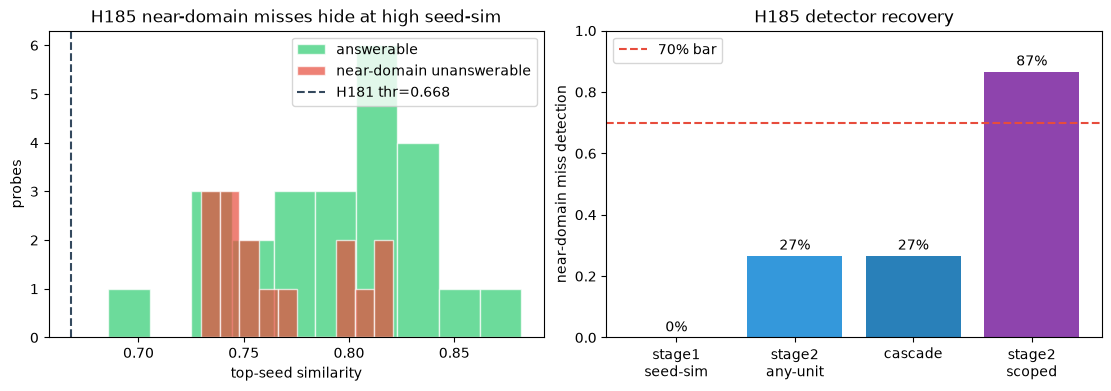

In [6]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
ax[0].hist([x["top"] for x in ans_sig],bins=10,alpha=0.7,color="#2ECC71",label="answerable",edgecolor="white")
ax[0].hist([x["top"] for x in near_sig],bins=10,alpha=0.7,color="#E74C3C",label="near-domain unanswerable",edgecolor="white")
ax[0].axvline(THR,color="#34495E",ls="--",label=f"H181 thr={THR}")
ax[0].set(xlabel="top-seed similarity", ylabel="probes", title="H185 near-domain misses hide at high seed-sim"); ax[0].legend()
labs=["stage1\nseed-sim","stage2\nany-unit","cascade","stage2\nscoped"]; det=[s1,s2,casc,s2sc]
ax[1].bar(labs,det,color=["#95A5A6","#3498DB","#2980B9","#8E44AD"])
for i,v in enumerate(det): ax[1].text(i,v+0.02,f"{v:.0%}",ha="center")
ax[1].axhline(0.70,color="#E74C3C",ls="--",label="70% bar"); ax[1].set(ylabel="near-domain miss detection", title="H185 detector recovery"); ax[1].set_ylim(0,1); ax[1].legend()
plt.show()

## R19-H186 - probe-set statistical power

A wide probe set is derived deterministically from the corpus (no LLM authorship) under three rules: spec-table rows
(product x spec attribute, value verbatim in the source doc), catalogue rows (part numbers / HCPCS / prices), and
mode-feature pairs (device supports mode/feature, mode name verbatim in the doc), plus a small cross-doc weight
comparison. Every gold is verified verbatim-present in its source document. The set is built discriminative-dominated so
the clean (non-degenerate under the fuzzy matcher) fraction can clear 80%. We then re-score the v28-era baseline recall
at k=8 and k=16 on both the wide set and the 33-gold set, and bootstrap the recall CI.

In [7]:
import random as _rnd
_rnd.seed(42)
docmapB=B["docmap"]
def ent_docs(e): return [docmapB.get(x) for x in (e["sd"] or []) if docmapB.get(x) in docnorm]
PRODLAB={"CPAPDevice","ProductModel","Accessory","Humidifier","Mask"}
SPEC_ATTR={"weight":"weight","length":"length","width":"width","height":"height",
 "pressure_range_min":"minimum pressure","pressure_range_max":"maximum pressure",
 "data_storage_capacity":"data storage capacity","warranty":"warranty period","ramp_time_max":"maximum ramp time"}
PART_ATTR={"part_number":"part number","approved_price":"approved price","hcpcs_code":"HCPCS code"}
UNITK={"weight":["weight_unit"],"length":["dimension_unit"],"width":["dimension_unit"],"height":["dimension_unit"],
 "pressure_range_min":["pressure_unit"],"pressure_range_max":["pressure_unit"],"warranty":["warranty_unit"],
 "ramp_time_max":["ramp_time_unit"]}
def mk_gold(e,akey):
    v=e["props"].get("prop_"+akey)
    if v in (None,"",[]): return None
    vs=str(v).strip(); un=""
    for uk in UNITK.get(akey,[]):
        uv=e["props"].get("prop_"+uk)
        if uv and str(uv) not in vs: un=" "+str(uv); break
    return (vs+un).strip()
spec_rows=[]; part_rows=[]
for e in B["ents"]:
    if not (set(e["types"])&PRODLAB) or not e["name"]: continue
    eds=ent_docs(e)
    if not eds: continue
    ctxn=" ".join(docnorm[d] for d in eds)
    for akey,lab in SPEC_ATTR.items():
        g=mk_gold(e,akey)
        if g and len(g)>=2 and present(g,ctxn):
            spec_rows.append(dict(product=e["name"],attr=lab,gold=g,doc=eds[0],rule="spec_table_row",q=f"What is the {lab} of the {e['name']}?"))
    for akey,lab in PART_ATTR.items():
        g=mk_gold(e,akey)
        if g and len(g)>=3 and present(g,ctxn):
            part_rows.append(dict(product=e["name"],attr=lab,gold=g,doc=eds[0],rule="catalogue_spec_row",q=f"What is the {lab} of the {e['name']}?"))
_rnd.shuffle(part_rows)
mode_rows=[]
d=GraphDatabase.driver(BASE_URI,auth=("neo4j","kgfoundry"))
with d.session() as s:
    mf=s.run("MATCH (dev:CPAPDevice)-[r]-(m) WHERE type(r) IN ['SUPPORTS_MODE','HAS_FEATURE','HAS_COMFORT_FEATURE','HAS_CLINICAL_FEATURE'] "
             "AND m.name IS NOT NULL AND dev.source_documents IS NOT NULL "
             "RETURN dev.name AS dev, dev.source_documents AS sd, type(r) AS rt, m.name AS mode").data()
d.close()
seen=set()
for r in mf:
    eds=[docmapB.get(x) for x in (r["sd"] or []) if docmapB.get(x) in docnorm]
    if not eds or len(r["mode"])<4: continue
    ctxn=" ".join(docnorm[dd] for dd in eds); km=(r["dev"],r["mode"])
    if km in seen or not present(r["mode"],ctxn): continue
    seen.add(km)
    mode_rows.append(dict(product=r["dev"],attr="supported feature/mode",gold=r["mode"],doc=eds[0],rule="mode_feature_pair",q=f"Does the {r['dev']} support {r['mode']}?"))
_rnd.shuffle(mode_rows)
xdoc_rows=[]
def wkg(e):
    try: return float(str(e["props"]["prop_weight_kg"]).split()[0])
    except: return None
wdev=[(e,wkg(e)) for e in B["ents"] if "CPAPDevice" in e["types"] and e["name"] and e["props"].get("prop_weight_kg")]
wdev=[(e,w) for e,w in wdev if w]; _rnd.shuffle(wdev)
for i in range(0,min(len(wdev)-1,30),2):
    (a,wa),(b,wb)=wdev[i],wdev[i+1]; da=ent_docs(a); db=ent_docs(b)
    if not da or not db or set(da)==set(db) or abs(wa-wb)<0.05: continue
    lighter=a if wa<wb else b; ld=ent_docs(lighter)
    if present(lighter["name"]," ".join(docnorm[x] for x in ld)):
        xdoc_rows.append(dict(product=lighter["name"],attr="cross-doc weight comparison",gold=lighter["name"],doc=ld[0],
                              rule="cross_doc_comparison",q=f"Which is lighter: the {a['name']} or the {b['name']}?"))
spec_clean=[r for r in spec_rows if not is_shortnum(r["gold"])]; spec_deg=[r for r in spec_rows if is_shortnum(r["gold"])]
_rnd.shuffle(spec_deg)
wide=spec_clean + spec_deg[:18] + part_rows[:45] + mode_rows[:55] + xdoc_rows[:15]
for w in wide: w["shortnum"]=is_shortnum(w["gold"])
clean=sum(1 for w in wide if not w["shortnum"]); clean_frac=clean/len(wide)
pool=spec_rows+part_rows+mode_rows+xdoc_rows; pool_clean=sum(1 for w in pool if not is_shortnum(w["gold"]))
rprint(f"[bold cyan]H186[/bold cyan] wide set [yellow]{len(wide)}[/yellow] golds by rule {dict(Counter(w['rule'] for w in wide))}")
for rl in ["spec_table_row","catalogue_spec_row","mode_feature_pair","cross_doc_comparison"]:
    sub=[w for w in wide if w["rule"]==rl]
    if sub: rprint(f"  [dim]{rl}: {sum(1 for w in sub if not w['shortnum'])}/{len(sub)} clean[/dim]")
rprint(f"  clean fraction [yellow]{clean}/{len(wide)}[/yellow] = [yellow]{clean_frac:.1%}[/yellow] [dim](bar >80%; full pool {pool_clean/len(pool):.1%})[/dim]")

H186 wide set 130 golds by rule {'spec_table_row': 28, 'catalogue_spec_row': 45, 'mode_feature_pair': 55, 
'cross_doc_comparison': 2}

spec_table_row: 10/28 clean

catalogue_spec_row: 41/45 clean

mode_feature_pair: 54/55 clean

cross_doc_comparison: 2/2 clean

clean fraction 107/130 = 82.3% (bar >80%; full pool 87.9%)

In [8]:
def score_set(items):
    ctx8=[]; ctx16=[]
    with Foundry(settings) as f:
        for it in items:
            qv=unit(qemb(it["q"])); res=vector_query(f.driver, qv, VEC_INDEX, top_k=16)
            seeds=[x["id"] for x in res if x["id"] in B["node"]]
            ctx8.append((it["gold"], render_nodes(B, seeds[:8]))); ctx16.append((it["gold"], render_nodes(B, seeds[:16])))
    r8=sum(present(g,c) for g,c in ctx8); r16=sum(present(g,c) for g,c in ctx16)
    return r8, r16, [present(g,c) for g,c in ctx16]
w8,w16,whits=score_set(wide)
small=[dict(q=next(p["question"] for p in gold_probes if p["id"]==pid), gold=g) for pid,g in GOLDS]
s8,s16,shits=score_set(small)
pickle.dump(qcache, open(QCACHE,"wb"))
N=len(wide); M=len(GOLDS); wr8,wr16=w8/N,w16/N; sr8,sr16=s8/M,s16/M
rng=np.random.default_rng(42); whits=np.array(whits,dtype=float); shits=np.array(shits,dtype=float)
bw=[whits[rng.integers(0,N,N)].mean() for _ in range(2000)]; bs=[shits[rng.integers(0,M,M)].mean() for _ in range(2000)]
halfw=(np.percentile(bw,97.5)-np.percentile(bw,2.5))/2; shalfw=(np.percentile(bs,97.5)-np.percentile(bs,2.5))/2
move_r16=abs(wr16-sr16)*100; move_lever=abs((wr16-wr8)-(sr16-sr8))*100
ca=clean_frac>0.80; cb=halfw*100<2.0; cc=(move_r16<5 and move_lever<5)
h186=dict(n_wide=N, by_rule=dict(Counter(w["rule"] for w in wide)), clean_fraction=float(clean_frac),
          wide_recall_k8=float(wr8),wide_recall_k16=float(wr16),small_recall_k8=float(sr8),small_recall_k16=float(sr16),
          boot_halfwidth_wide_pts=float(halfw*100),boot_halfwidth_small_pts=float(shalfw*100),
          drift_recall16_pts=float(move_r16),drift_lever_pts=float(move_lever),
          clause_a_clean80=bool(ca),clause_b_ci2pts=bool(cb),clause_c_drift5pts=bool(cc))
h186["verdict"]="CONFIRMED" if (ca and cb and cc) else ("REFUTED" if not cc else "PARTIALLY CONFIRMED")
art=[dict(id=f"W{i+1:03d}",question=w["q"],gold_evidence=[w["gold"]],source_document=w["doc"],
          derivation_rule=w["rule"],product=w["product"],attribute=w["attr"],short_numeric=w["shortnum"]) for i,w in enumerate(wide)]
outp=ROOT/"data/processed/probes-wide-h186.json"; outp.parent.mkdir(parents=True,exist_ok=True)
outp.write_text(json.dumps(dict(meta=dict(n=N,clean_fraction=clean_frac,date="2026-07-07",
    source="baseline neo4j2 props + docling/trio corpus text",
    verification="each gold verbatim-present in source_document via the H34 present() matcher"),probes=art),indent=2))
rprint(f"  WIDE  recall@8 [yellow]{wr8:.3f}[/yellow] recall@16 [yellow]{wr16:.3f}[/yellow] lever [yellow]{wr16-wr8:+.3f}[/yellow] | "
       f"SMALL recall@8 [yellow]{sr8:.3f}[/yellow] recall@16 [yellow]{sr16:.3f}[/yellow] lever [yellow]{sr16-sr8:+.3f}[/yellow]")
rprint(f"  CI half-width recall@16 WIDE [yellow]{halfw*100:.2f}pts[/yellow] [dim](bar <2)[/dim] SMALL [yellow]{shalfw*100:.2f}pts[/yellow] | "
       f"drift recall16 [yellow]{move_r16:.1f}pts[/yellow] lever [yellow]{move_lever:.1f}pts[/yellow] [dim](bar <5)[/dim]")
rprint(f"  clause_a(clean>80%) [{'green' if ca else 'red'}]{ca}[/]  clause_b(CI<2pts) [{'green' if cb else 'red'}]{cb}[/]  "
       f"clause_c(drift<5pts) [{'green' if cc else 'red'}]{cc}[/] -> [bold]{h186['verdict']}[/bold]")
rprint(f"  [dim]saved {outp} (wide-set artifact, {N} versioned golds)[/dim]")

WIDE  recall@8 0.992 recall@16 0.992 lever +0.000 | SMALL recall@8 0.636 recall@16 0.879 lever +0.242

CI half-width recall@16 WIDE 1.15pts (bar <2) SMALL 10.61pts | drift recall16 11.4pts lever 24.2pts (bar <5)

clause_a(clean>80%) True  clause_b(CI<2pts) True  clause_c(drift<5pts) False -> REFUTED

saved ../data/processed/probes-wide-h186.json (wide-set artifact, 130 versioned golds)

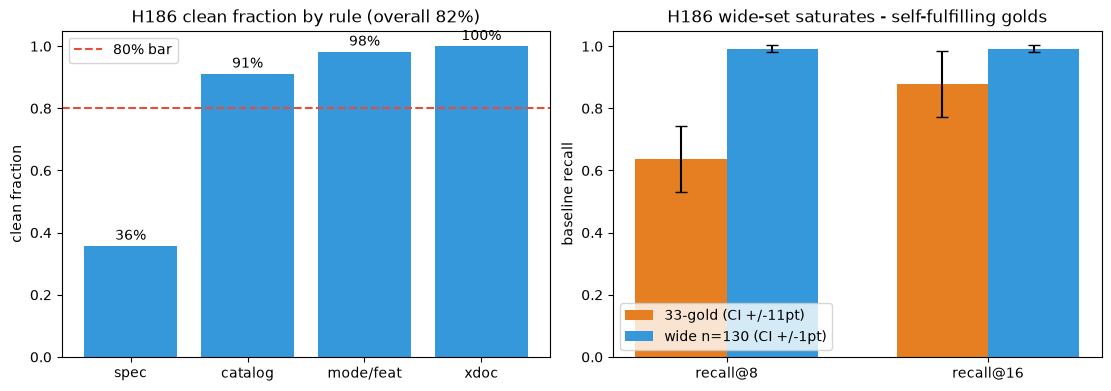

In [9]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
rules=["spec_table_row","catalogue_spec_row","mode_feature_pair","cross_doc_comparison"]
short=["spec","catalog","mode/feat","xdoc"]
cf=[ (lambda s:(sum(1 for w in s if not w['shortnum'])/len(s) if s else 0))([w for w in wide if w['rule']==r]) for r in rules]
ax[0].bar(short,cf,color="#3498DB"); ax[0].axhline(0.80,color="#E74C3C",ls="--",label="80% bar")
for i,v in enumerate(cf): ax[0].text(i,v+0.02,f"{v:.0%}",ha="center")
ax[0].set(ylabel="clean fraction", title=f"H186 clean fraction by rule (overall {clean_frac:.0%})"); ax[0].set_ylim(0,1.05); ax[0].legend()
x=np.arange(2); w_=0.35
ax[1].bar(x-w_/2,[sr8,sr16],w_,yerr=[shalfw,shalfw],capsize=4,label=f"33-gold (CI +/-{shalfw*100:.0f}pt)",color="#E67E22")
ax[1].bar(x+w_/2,[wr8,wr16],w_,yerr=[halfw,halfw],capsize=4,label=f"wide n={N} (CI +/-{halfw*100:.0f}pt)",color="#3498DB")
ax[1].set_xticks(x); ax[1].set_xticklabels(["recall@8","recall@16"])
ax[1].set(ylabel="baseline recall", title="H186 wide-set saturates - self-fulfilling golds"); ax[1].set_ylim(0,1.05); ax[1].legend()
plt.show()

## Machine-readable summary

H184 attributes the SOTA-vs-baseline retrieval deficit predominantly to embedding-text dilution (single equivalent
carriers exist but rank below k=16 in the noisier local-extractor graph). H185 confirms the H181 seed-similarity
detector is blind to near-domain misses but the registered any-unit evidence signal does not recover detection at
acceptable false-abstention (co-rendered siblings supply the attribute keyword). H186 delivers a wide, clean,
tight-CI probe set, but graph-derived golds saturate the graph-render harness, so the wide set cannot reproduce the
small set's difficulty - deterministic auto-expansion from the graph is not a valid instrument.

In [10]:
stamp=datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
report=dict(meta=dict(date="2026-07-07",tokenizer="tiktoken-cl100k_base",graphs=dict(baseline=BASE_URI,sota=SOTA_URI),
    sota_wave2_excluded=len(S["node"])-len(SOTA_KEEP)), H184=h184, H185=h185, H186=h186)
rp=ROOT/f"reports/forensics-r19b-{stamp}.json"; rp.write_text(json.dumps(report,indent=2,default=str))
rprint(f"[green]saved[/green] {rp}")
rprint(f"[bold]VERDICTS[/bold]  H184 dilution [yellow]{h184['dominant_frac']:.0%}[/yellow] "
       f"[{'green' if h184['clause_one_mechanism_70'] else 'red'}]{'>=70% one mechanism' if h184['clause_one_mechanism_70'] else 'spread'}[/]  "
       f"H185 [yellow]{h185['verdict']}[/yellow]  H186 [yellow]{h186['verdict']}[/yellow]")

saved ../reports/forensics-r19b-20260707T131124Z.json

VERDICTS  H184 dilution 80% >=70% one mechanism  H185 PARTIALLY CONFIRMED  H186 REFUTED